In [ ]:
import pandas as pd


In [4]:
df = pd.read_csv("/content/Housing.csv")

In [ ]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [6]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [7]:
# statistical calculations

In [8]:
print(df.mean(numeric_only=True))

price        4.766729e+06
area         5.150541e+03
bedrooms     2.965138e+00
bathrooms    1.286239e+00
stories      1.805505e+00
parking      6.935780e-01
dtype: float64


In [9]:
print(df.median(numeric_only=True))

price        4340000.0
area            4600.0
bedrooms           3.0
bathrooms          1.0
stories            2.0
parking            0.0
dtype: float64


In [10]:
print(df.mode().iloc[0])

price                      3500000
area                        6000.0
bedrooms                       3.0
bathrooms                      1.0
stories                        2.0
mainroad                       yes
guestroom                       no
basement                        no
hotwaterheating                 no
airconditioning                 no
parking                        0.0
prefarea                        no
furnishingstatus    semi-furnished
Name: 0, dtype: object


In [11]:
print(df.var(numeric_only=True))

price        3.498544e+12
area         4.709512e+06
bedrooms     5.447383e-01
bathrooms    2.524757e-01
stories      7.525432e-01
parking      7.423300e-01
dtype: float64


In [12]:
print(df.std(numeric_only=True))

price        1.870440e+06
area         2.170141e+03
bedrooms     7.380639e-01
bathrooms    5.024696e-01
stories      8.674925e-01
parking      8.615858e-01
dtype: float64


In [13]:
# skewness
print(df.skew(numeric_only=True))

price        1.212239
area         1.321188
bedrooms     0.495684
bathrooms    1.589264
stories      1.082088
parking      0.842062
dtype: float64


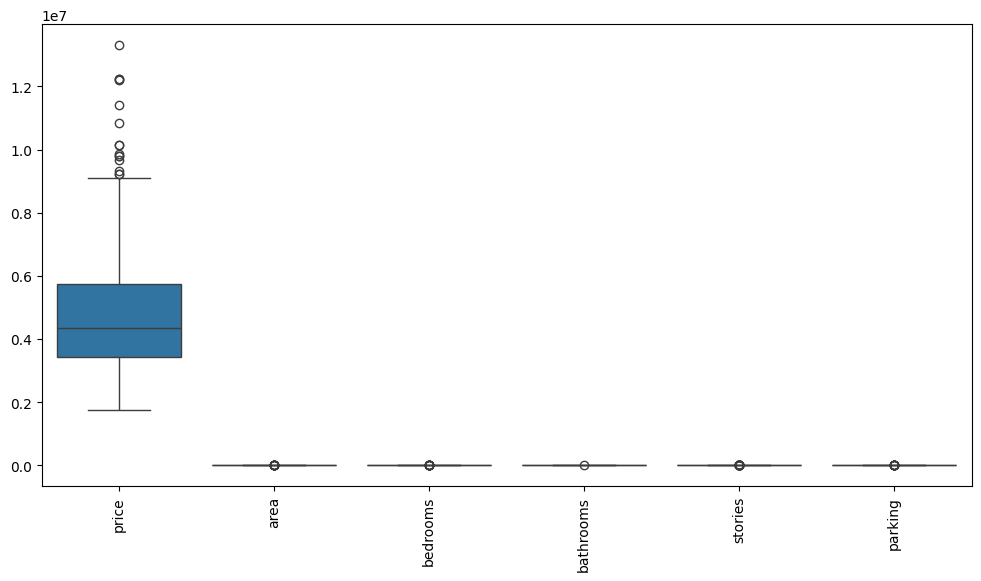

In [14]:
# detecting outliers
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.boxplot(data=df.select_dtypes(include="number"))
plt.xticks(rotation=90)
plt.show()

In [15]:
corr = df.corr(numeric_only=True)

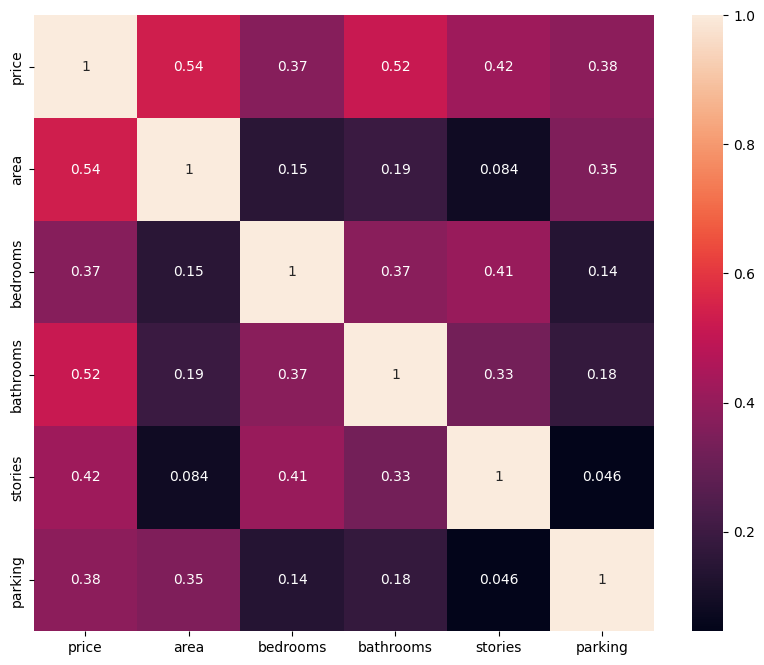

In [16]:
# correlation matrix
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True)
plt.show()

In [17]:
corr = df.corr(numeric_only=True)

print(corr["price"].sort_values(ascending=False))

price        1.000000
area         0.535997
bathrooms    0.517545
stories      0.420712
parking      0.384394
bedrooms     0.366494
Name: price, dtype: float64


In [22]:
# training the dataset

In [19]:
target = "price"

selected_features = corr[target].sort_values(ascending=False).index[1:6]

print(selected_features)

Index(['area', 'bathrooms', 'stories', 'parking', 'bedrooms'], dtype='object')


In [20]:
X = df[selected_features]
y = df[target]

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [23]:
# simple linear regression
from sklearn.linear_model import LinearRegression

slr = LinearRegression()
slr.fit(X_train[['area']], y_train)

slr_pred = slr.predict(X_test[['area']])

In [24]:
# multiplr linear regression
mlr = LinearRegression()

mlr.fit(X_train, y_train)

mlr_pred = mlr.predict(X_test)

In [25]:
# RMSE and R2

In [26]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

In [30]:
# Simple Linear Regression
rmse_slr = np.sqrt(mean_squared_error(y_test, slr_pred))
print("SLR RMSE:", rmse_slr)
print("SLR R²:", r2_score(y_test, slr_pred))

# Multiple Linear Regression
rmse_mlr = np.sqrt(mean_squared_error(y_test, mlr_pred))
print("MLR RMSE:", rmse_mlr)
print("MLR R²:", r2_score(y_test, mlr_pred))

SLR RMSE: 1917103.7021424233
SLR R²: 0.27287851871974644
MLR RMSE: 1514173.552049223
MLR R²: 0.5464062355495873


In [33]:
# Best model
if rmse_mlr < rmse_slr:
    best_model = mlr
    print("Best Model: Multiple Linear Regression")
else:
    best_model = slr
    print("Best Model: Simple Linear Regression")

Best Model: Multiple Linear Regression


In [34]:
# predicting 10 unseen houses
unseen = X_test.head(10)

predictions = best_model.predict(unseen)

print(predictions)

[6178627.50326817 6370140.85865473 3283148.1570249  4226007.94816032
 3409685.55116741 4262158.3499693  5493440.53152357 5559897.74293016
 3373715.42245305 3020513.18649698]


In [35]:
# saving the trained model
import joblib

joblib.dump(best_model, "house_price_model.pkl")

print("Model saved successfully!")

Model saved successfully!
